<a href="https://colab.research.google.com/github/estheromoyiwola/Team-Energy-Load-Forecasting/blob/main/Team6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Extraction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read csv
import pandas as pd
base_path = "/content/drive/MyDrive/DS & ML Research Team_Spring_26/Esther_ReviewPapers_Dataset/ashrae_data/" # This because i am running from mine

In [ ]:
# read the datasets
df_train = pd.read_csv(f"{base_path}/train.csv")
df_weather = pd.read_csv(f"{base_path}/weather_train.csv")
df_building_metadata = pd.read_csv(f"{base_path}/building_metadata.csv")

## Data Preprocessing

In [ ]:
df_train.head(5)

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [ ]:
df_weather.head(5)

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
df_building_metadata.head(5)

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [ ]:
len(df_train.building_id.unique())

1449

In [ ]:
len(df_building_metadata.building_id.unique())

1449

In [ ]:
df_train.shape

(20216100, 4)

In [ ]:
df_train.isnull().sum()

,0
building_id,0
meter,0
timestamp,0
meter_reading,0


In [ ]:
df_building_metadata.shape

(1449, 6)

In [ ]:
df_train[df_train.building_id == 0]

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.000
2301,0,0,2016-01-01 01:00:00,0.000
4594,0,0,2016-01-01 02:00:00,0.000
6893,0,0,2016-01-01 03:00:00,0.000
9189,0,0,2016-01-01 04:00:00,0.000
...,...,...,...,...
20204274,0,0,2016-12-31 19:00:00,232.071
20206637,0,0,2016-12-31 20:00:00,189.069
20209003,0,0,2016-12-31 21:00:00,169.958
20211368,0,0,2016-12-31 22:00:00,169.958


### Data Merging

In [ ]:
df_train_merged = df_train.merge(df_building_metadata, on='building_id', how='left') #Merged train and metadata together

In [ ]:
df_train_merged.head(5)

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN


In [ ]:
df_weather.head(5)

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
df_weather.shape

(139773, 9)

In [ ]:
df_train_merged.shape

(20216100, 9)

In [ ]:
df_finalmerge = df_train_merged.merge(df_weather, on= ['site_id', 'timestamp'], how='left')

In [ ]:
print("Dataset Shape:", df_finalmerge.shape)

print("\nNumber of Unique Buildings:", df_finalmerge['building_id'].nunique())
print("Number of Unique Sites:", df_finalmerge['site_id'].nunique())

print("\nDate Range:")
print("Start:", df_finalmerge['timestamp'].min())
print("End:", df_finalmerge['timestamp'].max())

print("\nMeter Types Distribution:")
print(df_finalmerge['meter'].value_counts())

Dataset Shape: (20216100, 16)

Number of Unique Buildings: 1449
Number of Unique Sites: 16

Date Range:
Start: 2016-01-01 00:00:00
End: 2016-12-31 23:00:00

Meter Types Distribution:
meter
0    12060910
1     4182440
2     2708713
3     1264037
Name: count, dtype: int64


In [ ]:
df_finalmerge.head(5)

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


### Data Manipulation

In [ ]:
df_finalmerge['timestamp'] = pd.to_datetime(df_finalmerge['timestamp'])

df_finalmerge['hour'] = df_finalmerge['timestamp'].dt.hour
df_finalmerge['dayofweek'] = df_finalmerge['timestamp'].dt.dayofweek
df_finalmerge['month'] = df_finalmerge['timestamp'].dt.month
df_finalmerge['year'] = df_finalmerge['timestamp'].dt.year

In [ ]:
df_finalmerge.head(5)

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,dayofweek,month,year
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,0,4,1,2016
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,0,4,1,2016
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,0,4,1,2016
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,0,4,1,2016
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,0,4,1,2016


In [ ]:
df_finalmerge.tail(5)

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,dayofweek,month,year
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,5,12,2016
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,5,12,2016
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,5,12,2016
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,5,12,2016
20216099,1448,0,2016-12-31 23:00:00,2.850,15,Office,92271,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,5,12,2016


In [ ]:
missing_counts = df_finalmerge.isnull().sum().sort_values(ascending=False)   #checking missing columns
print(missing_counts)

floor_count           16709167
year_built            12127645
cloud_coverage         8825365
precip_depth_1_hr      3749023
wind_direction         1449048
sea_level_pressure     1231669
wind_speed              143676
dew_temperature         100140
air_temperature          96658
timestamp                    0
meter                        0
building_id                  0
meter_reading                0
primary_use                  0
square_feet                  0
site_id                      0
hour                         0
dayofweek                    0
month                        0
year                         0
dtype: int64


In [ ]:
missing_pct = (df_finalmerge.isnull().sum() / len(df_finalmerge)) * 100    #checking missing columns in percentage
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_summary.head(15))

                    Missing Count  Missing %
floor_count              16709167  82.652772
year_built               12127645  59.990033
cloud_coverage            8825365  43.655131
precip_depth_1_hr         3749023  18.544739
wind_direction            1449048   7.167792
sea_level_pressure        1231669   6.092515
wind_speed                 143676   0.710701
dew_temperature            100140   0.495348
air_temperature             96658   0.478124
building_id                     0   0.000000
dayofweek                       0   0.000000
hour                            0   0.000000
primary_use                     0   0.000000
month                           0   0.000000
meter_reading                   0   0.000000


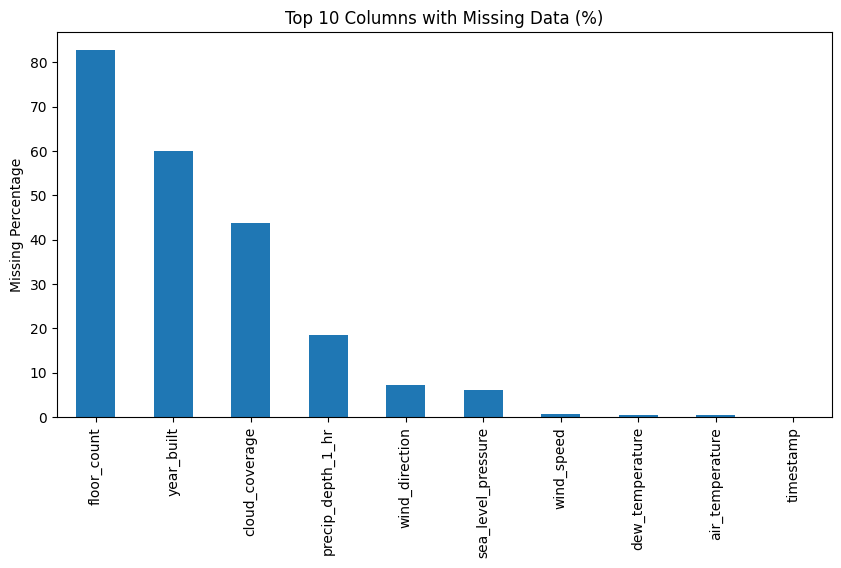

In [ ]:
import matplotlib.pyplot as plt        #the distribution of missing columns

missing_pct.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Columns with Missing Data (%)")
plt.ylabel("Missing Percentage")
plt.show()

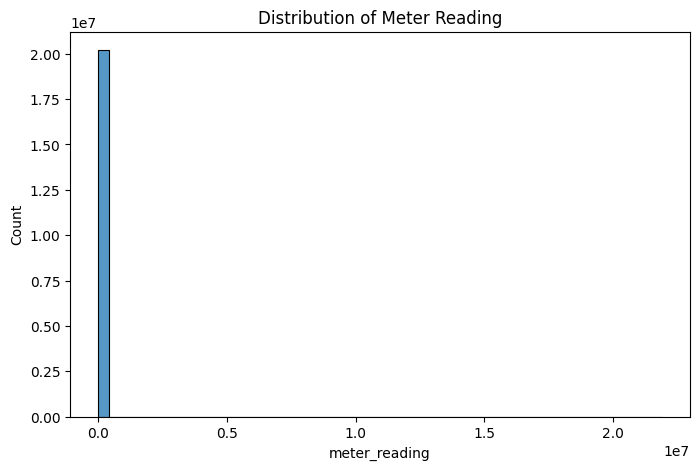

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_finalmerge['meter_reading'], bins=50)
plt.title("Distribution of Meter Reading")
plt.show()

In [ ]:
print("Skewness:", df_finalmerge['meter_reading'].skew())

Skewness: 104.81131369454751


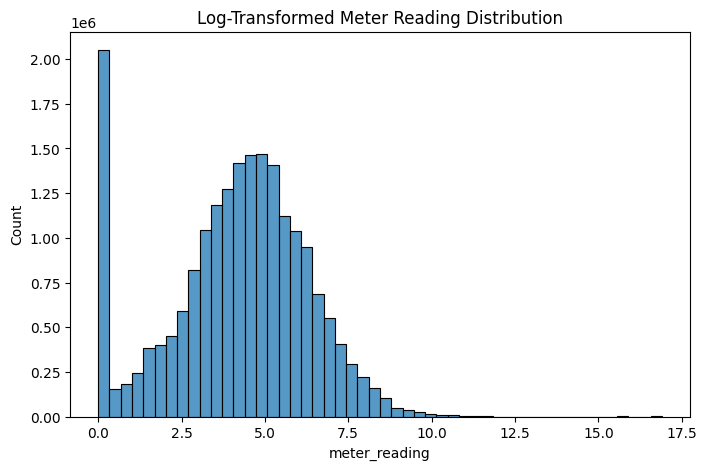

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_finalmerge['meter_reading']), bins=50)
plt.title("Log-Transformed Meter Reading Distribution")
plt.show()

site_id
0     105
1      51
2     135
3     274
4      91
5      89
6      44
7      15
8      70
9     124
10     30
11      5
12     36
13    154
14    102
15    124
Name: building_id, dtype: int64


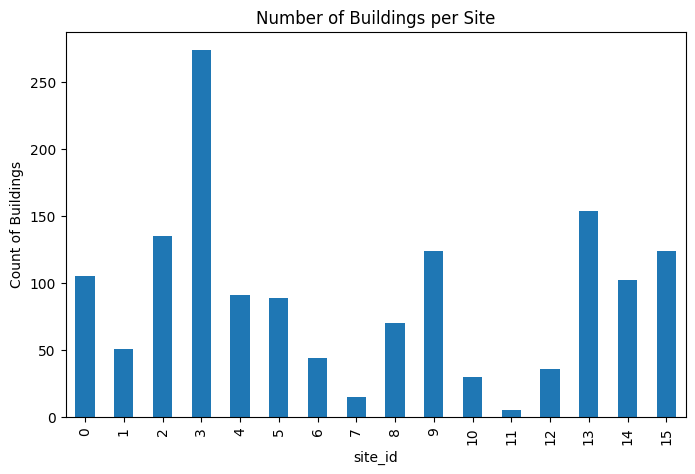

In [ ]:
buildings_per_site = df_finalmerge.groupby('site_id')['building_id'].nunique()

print(buildings_per_site)

plt.figure(figsize=(8,5))
buildings_per_site.plot(kind='bar')
plt.title("Number of Buildings per Site")
plt.ylabel("Count of Buildings")
plt.show()

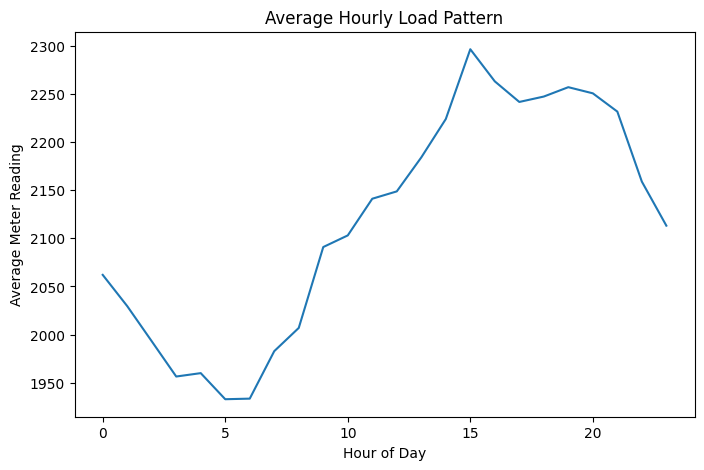

In [ ]:
hourly_avg = df_finalmerge.groupby('hour')['meter_reading'].mean()

plt.figure(figsize=(8,5))
hourly_avg.plot()
plt.title("Average Hourly Load Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.show()

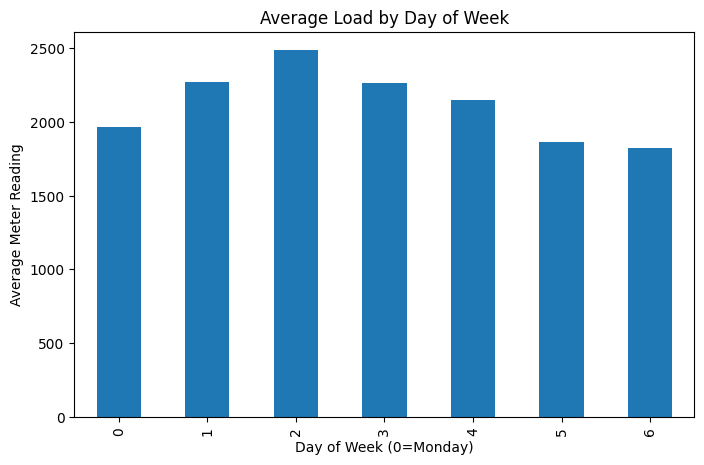

In [ ]:
weekly_avg = df_finalmerge.groupby('dayofweek')['meter_reading'].mean()

plt.figure(figsize=(8,5))
weekly_avg.plot(kind='bar')
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Average Meter Reading")
plt.show()

In [ ]:
df_finalmerge['meter_reading']

,meter_reading
0,0.000
1,0.000
2,0.000
3,0.000
4,0.000
...,...
20216095,8.750
20216096,4.825
20216097,0.000
20216098,159.575


In [ ]:
print(df_finalmerge[['meter_reading','air_temperature']].corr()) #temperature and load relationship

                 meter_reading  air_temperature
meter_reading         1.000000        -0.004132
air_temperature      -0.004132         1.000000


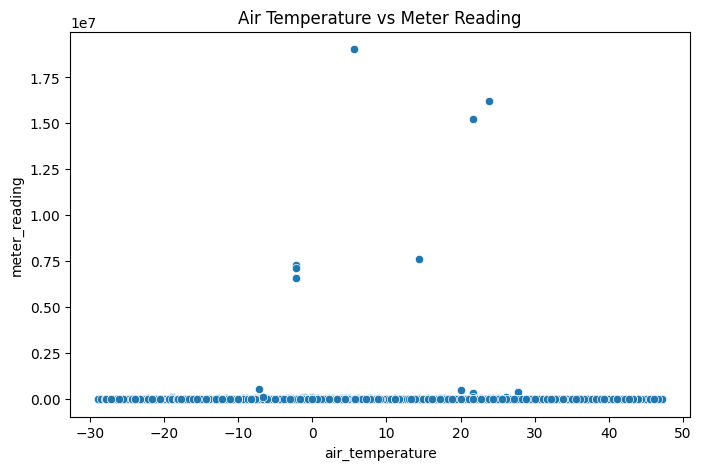

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='air_temperature', y='meter_reading', data=df_finalmerge.sample(50000))
plt.title("Air Temperature vs Meter Reading")
plt.show()

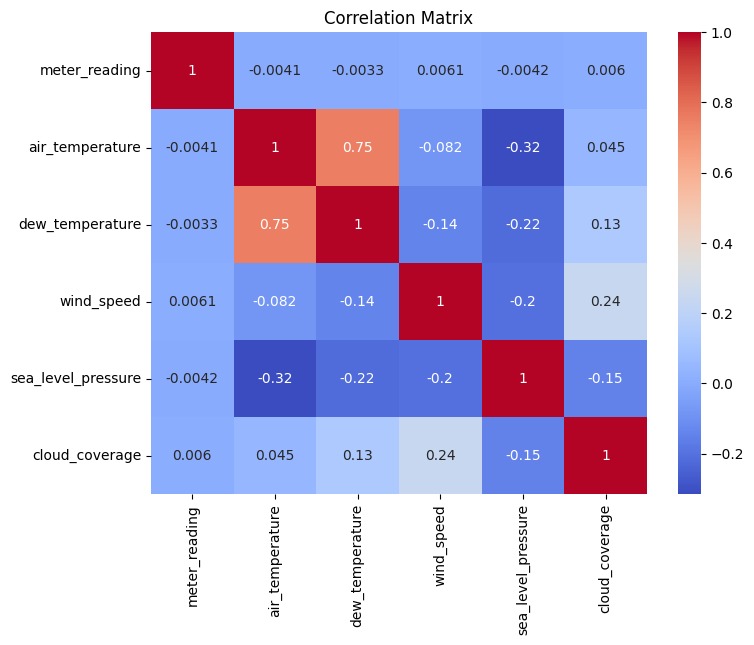

In [ ]:
corr_matrix = df_finalmerge[['meter_reading','air_temperature','dew_temperature',
                             'wind_speed','sea_level_pressure','cloud_coverage']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
weather_missing = df_finalmerge[['air_temperature','dew_temperature']].isnull().mean()*100
print(weather_missing)

air_temperature    0.478124
dew_temperature    0.495348
dtype: float64


In [ ]:
data

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.000
1,1,0,2016-01-01 00:00:00,0.000
2,2,0,2016-01-01 00:00:00,0.000
3,3,0,2016-01-01 00:00:00,0.000
4,4,0,2016-01-01 00:00:00,0.000
...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750
20216096,1445,0,2016-12-31 23:00:00,4.825
20216097,1446,0,2016-12-31 23:00:00,0.000
20216098,1447,0,2016-12-31 23:00:00,159.575


In [ ]:
df_weather

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6
...,...,...,...,...,...,...,...,...,...
139768,15,2016-12-31 19:00:00,3.0,NaN,-8.0,NaN,NaN,180.0,5.7
139769,15,2016-12-31 20:00:00,2.8,2.0,-8.9,NaN,1007.4,180.0,7.7
139770,15,2016-12-31 21:00:00,2.8,NaN,-7.2,NaN,1007.5,180.0,5.1
139771,15,2016-12-31 22:00:00,2.2,NaN,-6.7,NaN,1008.0,170.0,4.6


In [ ]:
df_building_metadata

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN
...,...,...,...,...,...,...
1444,15,1444,Entertainment/public assembly,19619,1914.0,NaN
1445,15,1445,Education,4298,NaN,NaN
1446,15,1446,Entertainment/public assembly,11265,1997.0,NaN
1447,15,1447,Lodging/residential,29775,2001.0,NaN
